In [1]:
import bcrypt
import pandas as pd
import matplotlib.pyplot as plt

password = "Test@123"

hashed = bcrypt.hashpw(password.encode(), bcrypt.gensalt())

print("Environment OK")
print("Hashed Password:", hashed)

Environment OK
Hashed Password: b'$2b$12$IpceaJt7qNKYbgey9wy9DeAtgVcMEzPvxuVNj/8JakODk7Xwxt/De'


In [2]:
import pandas as pd
import bcrypt
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [3]:
import pandas as pd
import bcrypt
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [4]:
import pandas as pd


In [5]:
print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
df = pd.read_csv("data/sample_passwords.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/sample_passwords.csv'

In [7]:
df = pd.read_csv("D:\Cognetix_Internship_Cybersecurity\3_Password Security Analysis & Policy Design\data\sample_password.csv")


OSError: [Errno 22] Invalid argument: 'D:\\Cognetix_Internship_Cybersecurity\x03_Password Security Analysis & Policy Design\\data\\sample_password.csv'

In [8]:
df = pd.read_csv("D:\Cognetix_Internship_Cybersecurity\3_Password Security Analysis & Policy Design\data\sample_passwords.csv")


OSError: [Errno 22] Invalid argument: 'D:\\Cognetix_Internship_Cybersecurity\x03_Password Security Analysis & Policy Design\\data\\sample_passwords.csv'

In [9]:
df = pd.read_csv 'D:\\Cognetix_Internship_Cybersecurity\x03_Password Security Analysis & Policy Design\\data\\sample_passwords.csv'


SyntaxError: invalid syntax (3605830099.py, line 1)

In [10]:
df = pd.read_csv(r"D:\Cognetix_Internship_Cybersecurity\03_Password Security Analysis & Policy Design\data\sample_passwords.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Cognetix_Internship_Cybersecurity\\03_Password Security Analysis & Policy Design\\data\\sample_passwords.csv'

In [11]:
df = pd.read_csv("D:/Cognetix_Internship_Cybersecurity/03_Password Security Analysis & Policy Design/data/sample_passwords.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'D:/Cognetix_Internship_Cybersecurity/03_Password Security Analysis & Policy Design/data/sample_passwords.csv'

In [12]:
import os
print(os.getcwd())

D:\Cognetix_Internship_Cybersecurity\3_Password Security Analysis & Policy Design\notebooks


In [13]:
import pandas as pd

df = pd.read_csv("../data/sample_passwords.csv")
df.head()

,username\tpassword
0,user1\tpassword123
1,user2\tWelcome@123
2,user3\tadmin
3,user4\tPassword@123
4,user5\tabc123


In [14]:
print(df.columns)

Index(['username\tpassword'], dtype='str')


In [15]:
import pandas as pd

df = pd.read_csv("../data/sample_passwords.csv", sep="\t")

df.head()

,username,password
0,user1,password123
1,user2,Welcome@123
2,user3,admin
3,user4,Password@123
4,user5,abc123


In [16]:
print(df.columns)

Index(['username', 'password'], dtype='str')


In [17]:
import re

def password_strength(password):
    score = 0

    # Rule 1: Length at least 8 characters
    if len(password) >= 8:
        score += 1

    # Rule 2: Contains uppercase letter
    if re.search(r"[A-Z]", password):
        score += 1

    # Rule 3: Contains lowercase letter
    if re.search(r"[a-z]", password):
        score += 1

    # Rule 4: Contains a digit
    if re.search(r"\d", password):
        score += 1

    # Rule 5: Contains a special character
    if re.search(r"[!@#$%^&*(),.?\":{}|<>]", password):
        score += 1

    return score

In [18]:
df["Strength Score"] = df["password"].apply(password_strength)

df.head()

,username,password,Strength Score
0,user1,password123,3
1,user2,Welcome@123,5
2,user3,admin,1
3,user4,Password@123,5
4,user5,abc123,2


In [19]:
def classify(score):
    if score <= 2:
        return "Weak"
    elif score <= 4:
        return "Moderate"
    else:
        return "Strong"

df["Strength"] = df["Strength Score"].apply(classify)

df

,username,password,Strength Score,Strength
0,user1,password123,3,Moderate
1,user2,Welcome@123,5,Strong
2,user3,admin,1,Weak
3,user4,Password@123,5,Strong
4,user5,abc123,2,Weak
5,user6,password123,3,Moderate
6,user7,Test@2025,5,Strong
7,user8,Qwerty,2,Weak
8,user9,Secure#789,5,Strong
9,user10,Admin123,4,Moderate


In [20]:
reused_passwords = df[df.duplicated('password', keep=False)]

print("Reused Passwords:")
reused_passwords

Reused Passwords:


,username,password,Strength Score,Strength
0,user1,password123,3,Moderate
1,user2,Welcome@123,5,Strong
5,user6,password123,3,Moderate
14,user15,password123,3,Moderate
15,user16,Welcome@123,5,Strong


In [21]:
password_frequency = df['password'].value_counts()

print(password_frequency)

password
password123           3
Welcome@123           2
admin                 1
Password@123          1
abc123                1
Test@2025             1
Qwerty                1
Secure#789            1
Admin123              1
hello123              1
Strong@456            1
iloveyou              1
Pass@2024             1
Sunshine1             1
Cyber@2025            1
12345678              1
MySecure#Password1    1
Name: count, dtype: int64


In [22]:
reuse_df = password_frequency.reset_index()
reuse_df.columns = ['Password', 'Frequency']

reuse_df

,Password,Frequency
0,password123,3
1,Welcome@123,2
2,admin,1
3,Password@123,1
4,abc123,1
5,Test@2025,1
6,Qwerty,1
7,Secure#789,1
8,Admin123,1
9,hello123,1


In [23]:
import bcrypt

def hash_password(password):
    # Generate salt and hash the password
    hashed = bcrypt.hashpw(password.encode('utf-8'), bcrypt.gensalt())

    # Convert bytes to string for easier display
    return hashed.decode('utf-8')

In [24]:
df["Hashed Password"] = df["password"].apply(hash_password)

df.head()

,username,password,Strength Score,Strength,Hashed Password
0,user1,password123,3,Moderate,$2b$12$THKAXG6BzKx/eB6QaH45N.f0tM4a/6EUif84yEF...
1,user2,Welcome@123,5,Strong,$2b$12$g4sIw19yBylofZTMJNThde0hJvxvb7U8l9e.AjJ...
2,user3,admin,1,Weak,$2b$12$g3WKtOiuDEmBZ6JkNpVJluFOUHdG3DkGX/7HZVW...
3,user4,Password@123,5,Strong,$2b$12$v4EiptXrmqTjDmtyQH7RR.CTgMZx4nhLNyJw9C6...
4,user5,abc123,2,Weak,$2b$12$mXOQQU9PDbjcujl/FbiL5OUBHadJbWMkkTZ79H9...


In [25]:
comparison = df[["username", "password", "Hashed Password"]]

comparison

,username,password,Hashed Password
0,user1,password123,$2b$12$THKAXG6BzKx/eB6QaH45N.f0tM4a/6EUif84yEF...
1,user2,Welcome@123,$2b$12$g4sIw19yBylofZTMJNThde0hJvxvb7U8l9e.AjJ...
2,user3,admin,$2b$12$g3WKtOiuDEmBZ6JkNpVJluFOUHdG3DkGX/7HZVW...
3,user4,Password@123,$2b$12$v4EiptXrmqTjDmtyQH7RR.CTgMZx4nhLNyJw9C6...
4,user5,abc123,$2b$12$mXOQQU9PDbjcujl/FbiL5OUBHadJbWMkkTZ79H9...
5,user6,password123,$2b$12$zEC1Sc5.UPa.RDqjqS.R0OD91x1n6IlzaxCs.C4...
6,user7,Test@2025,$2b$12$2LiZ/Nhwbf4WTYsBnyg3BeaE0sjSyI8JweHDSTM...
7,user8,Qwerty,$2b$12$.K3quCPBq6wNVviEW83qB.hWGLdHWSJ.sXaeV4Y...
8,user9,Secure#789,$2b$12$WCOOnw4JCnb.f/RdtC3htumoHBbjsY1M7.hspRP...
9,user10,Admin123,$2b$12$aRSSxFLZmGfMqRGfoTS3tOCoZ5uK4WZH09x/upk...


In [26]:
plain_password = "password123"

stored_hash = df.loc[df["username"] == "user1", "Hashed Password"].values[0]

result = bcrypt.checkpw(
    plain_password.encode("utf-8"),
    stored_hash.encode("utf-8")
)

print("Password Match:", result)

Password Match: True


In [27]:
df['password'].value_counts()

password
password123           3
Welcome@123           2
admin                 1
Password@123          1
abc123                1
Test@2025             1
Qwerty                1
Secure#789            1
Admin123              1
hello123              1
Strong@456            1
iloveyou              1
Pass@2024             1
Sunshine1             1
Cyber@2025            1
12345678              1
MySecure#Password1    1
Name: count, dtype: int64

In [28]:
import bcrypt

In [29]:
def hash_password(password):
    return bcrypt.hashpw(password.encode(), bcrypt.gensalt()).decode()

In [30]:
df['Hashed Password'] = df['Password'].apply(hash_password)

KeyError: 'Password'

In [31]:
df['Hashed Password'] = df['password'].apply(hash_password)

In [32]:
df[['password', 'Hashed Password']]

,password,Hashed Password
0,password123,$2b$12$HvlX0Boj5gx1JrCTwGyfY.M54dIbn5N50BEsPtS...
1,Welcome@123,$2b$12$zGismoX8K.l9Z4WbE.2ePefPDyNKAVXlDUcjMQb...
2,admin,$2b$12$9dlmlPRh9g5t2mMfMDod7OAbldYozEL5vGf66WP...
3,Password@123,$2b$12$a1pYwX.b9kt4paCwxYEo/OWjftVCcdg9OkRdw4S...
4,abc123,$2b$12$7/u1r5j3MDyJW4QA/8S7MOcqEuO27SC4ucVMsHO...
5,password123,$2b$12$hHoTsWTfsxbsWmxGvmeREe81l/5qOZK8684lWz/...
6,Test@2025,$2b$12$qhRZhYOj4DgfiOZooNM2MOA9rHv8uEOIUZLpdiy...
7,Qwerty,$2b$12$w8/qEw8B8XuAtnJeZfYa/ufcjIqH2.jNL21ByqZ...
8,Secure#789,$2b$12$.zEHLpMePkZtybxAuHadsuB28GqqXGERWBgKQa1...
9,Admin123,$2b$12$LLIHsDkZTiwpGxXwRO3lFOaiOuP2J2DvDg9K90s...


In [33]:
comparison_df = df[['password', 'Score', 'Hashed Password']]
comparison_df

KeyError: "['Score'] not in index"

In [34]:
comparison_df = df[['password', 'score', 'Hashed Password']]
comparison_df

KeyError: "['score'] not in index"

In [35]:
comparison_df = df[['password', 'Strength Score', 'Hashed Password']]
comparison_df

,password,Strength Score,Hashed Password
0,password123,3,$2b$12$HvlX0Boj5gx1JrCTwGyfY.M54dIbn5N50BEsPtS...
1,Welcome@123,5,$2b$12$zGismoX8K.l9Z4WbE.2ePefPDyNKAVXlDUcjMQb...
2,admin,1,$2b$12$9dlmlPRh9g5t2mMfMDod7OAbldYozEL5vGf66WP...
3,Password@123,5,$2b$12$a1pYwX.b9kt4paCwxYEo/OWjftVCcdg9OkRdw4S...
4,abc123,2,$2b$12$7/u1r5j3MDyJW4QA/8S7MOcqEuO27SC4ucVMsHO...
5,password123,3,$2b$12$hHoTsWTfsxbsWmxGvmeREe81l/5qOZK8684lWz/...
6,Test@2025,5,$2b$12$qhRZhYOj4DgfiOZooNM2MOA9rHv8uEOIUZLpdiy...
7,Qwerty,2,$2b$12$w8/qEw8B8XuAtnJeZfYa/ufcjIqH2.jNL21ByqZ...
8,Secure#789,5,$2b$12$.zEHLpMePkZtybxAuHadsuB28GqqXGERWBgKQa1...
9,Admin123,4,$2b$12$LLIHsDkZTiwpGxXwRO3lFOaiOuP2J2DvDg9K90s...


In [36]:
import matplotlib.pyplot as plt

FileNotFoundError: [Errno 2] No such file or directory: 'reports/password_strength.png'

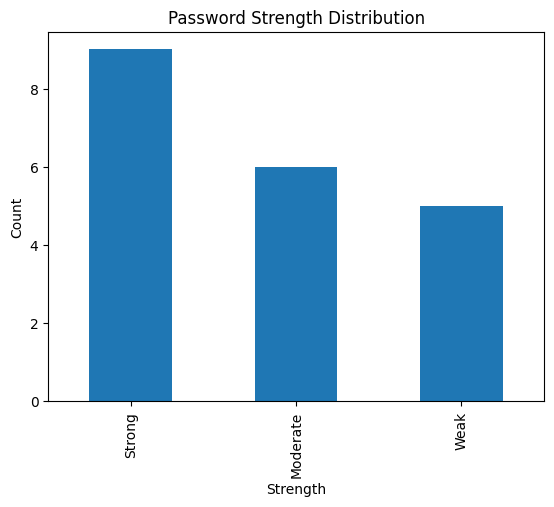

In [37]:
df['Strength'].value_counts().plot(kind='bar')
plt.title("Password Strength Distribution")
plt.xlabel("Strength")
plt.ylabel("Count")

plt.savefig("reports/password_strength.png")
plt.show()

In [38]:
import os

os.makedirs("reports", exist_ok=True)

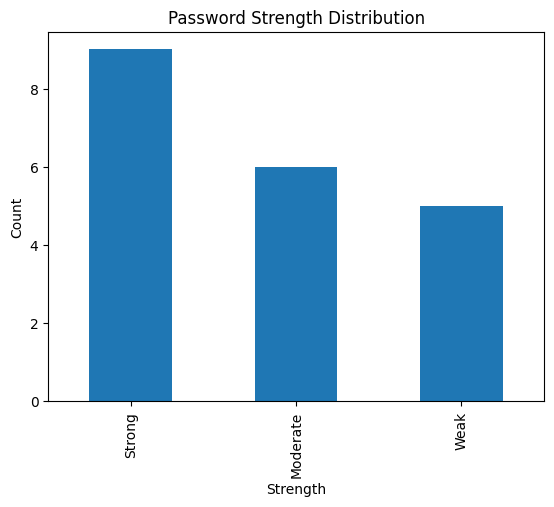

In [39]:
df['Strength'].value_counts().plot(kind='bar')
plt.title("Password Strength Distribution")
plt.xlabel("Strength")
plt.ylabel("Count")

plt.savefig("reports/password_strength.png")
plt.show()

In [40]:
df['Length'] = df['password'].apply(len)

In [41]:
plt.scatter(df['Length'], df['Score'])
plt.title("Password Length vs Strength Score")
plt.xlabel("Password Length")
plt.ylabel("Score")

plt.savefig("reports/password_length.png")
plt.show()

KeyError: 'Score'

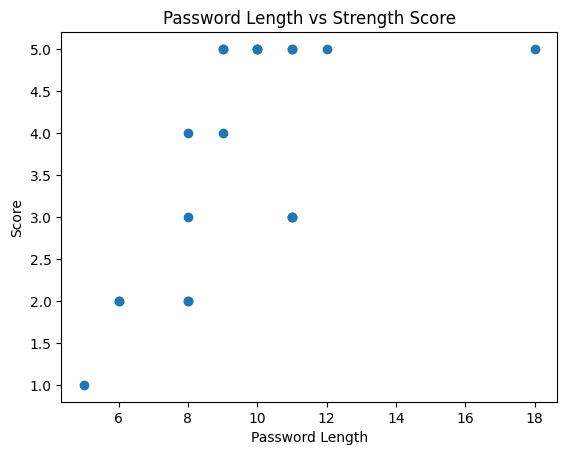

In [42]:
plt.scatter(df['Length'], df['Strength Score'])
plt.title("Password Length vs Strength Score")
plt.xlabel("Password Length")
plt.ylabel("Score")

plt.savefig("reports/password_length.png")
plt.show()

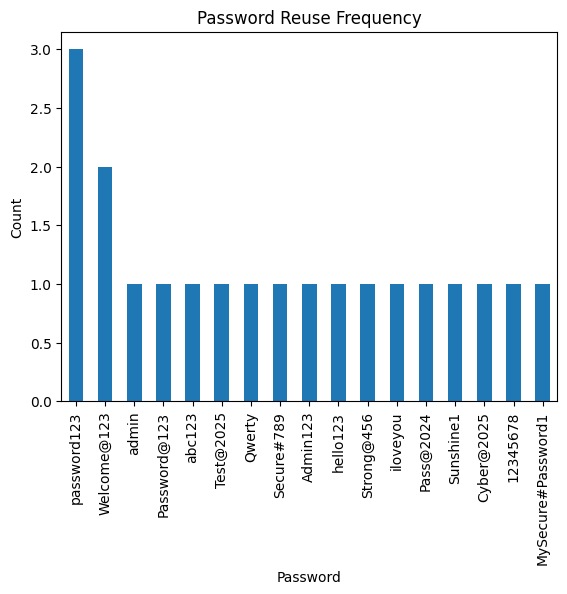

In [43]:
df['password'].value_counts().plot(kind='bar')
plt.title("Password Reuse Frequency")
plt.xlabel("Password")
plt.ylabel("Count")

plt.savefig("reports/reuse_frequency.png")
plt.show()

In [44]:
# Findings

1. Weak passwords exist in the dataset.
2. Some passwords are reused multiple times.
3. Strong passwords have higher scores.
4. Hashing improves password security.
5. Plaintext passwords are insecure and should never be stored.

SyntaxError: invalid syntax (430501135.py, line 3)

# Findings

1. Weak passwords exist in the dataset.
2. Some passwords are reused multiple times.
3. Strong passwords have higher scores.
4. Hashing improves password security.
5. Plaintext passwords are insecure and should never be stored.

In [45]:
df.columns

Index(['username', 'password', 'Strength Score', 'Strength', 'Hashed Password',
       'Length'],
      dtype='str')

In [46]:
df['password'].value_counts()

password
password123           3
Welcome@123           2
admin                 1
Password@123          1
abc123                1
Test@2025             1
Qwerty                1
Secure#789            1
Admin123              1
hello123              1
Strong@456            1
iloveyou              1
Pass@2024             1
Sunshine1             1
Cyber@2025            1
12345678              1
MySecure#Password1    1
Name: count, dtype: int64

<Axes: xlabel='Strength'>

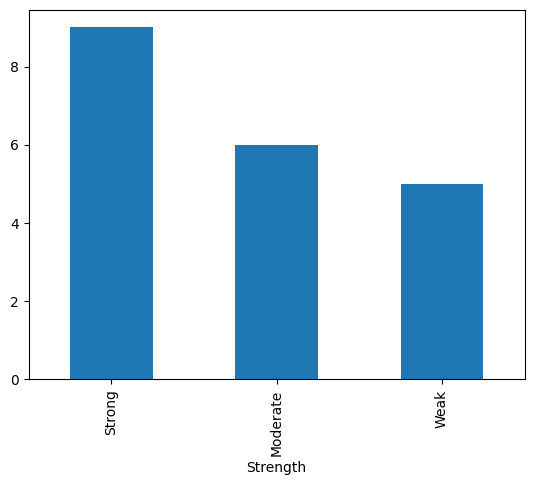

In [47]:
df['Strength'].value_counts().plot(kind='bar')

In [48]:
df['Length'] = df['password'].apply(len)
df.head()

,username,password,Strength Score,Strength,Hashed Password,Length
0,user1,password123,3,Moderate,$2b$12$HvlX0Boj5gx1JrCTwGyfY.M54dIbn5N50BEsPtS...,11
1,user2,Welcome@123,5,Strong,$2b$12$zGismoX8K.l9Z4WbE.2ePefPDyNKAVXlDUcjMQb...,11
2,user3,admin,1,Weak,$2b$12$9dlmlPRh9g5t2mMfMDod7OAbldYozEL5vGf66WP...,5
3,user4,Password@123,5,Strong,$2b$12$a1pYwX.b9kt4paCwxYEo/OWjftVCcdg9OkRdw4S...,12
4,user5,abc123,2,Weak,$2b$12$7/u1r5j3MDyJW4QA/8S7MOcqEuO27SC4ucVMsHO...,6


In [49]:
plt.scatter(df['Length'], df['Score'])

KeyError: 'Score'

In [50]:
plt.scatter(df['Length'], df['score'])

KeyError: 'score'

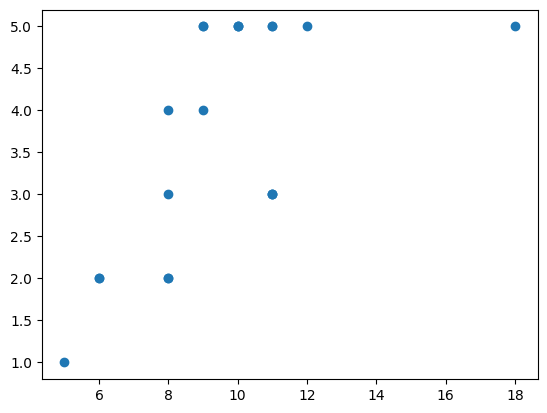

In [51]:
plt.scatter(df['Length'], df['Strength Score'])

<Axes: xlabel='password'>

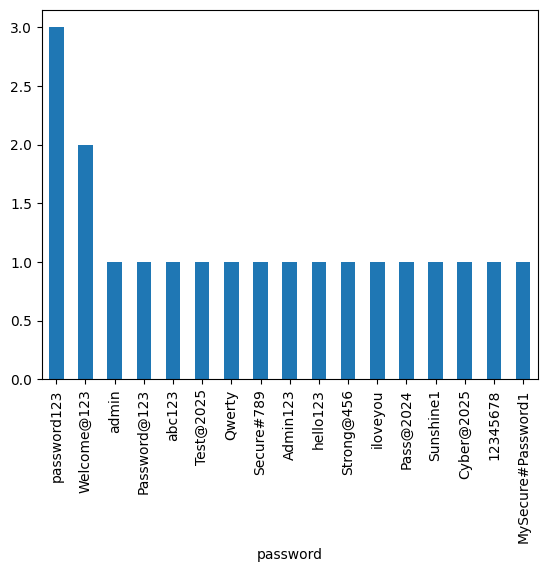

In [52]:
df['password'].value_counts().plot(kind='bar')

In [53]:
df[['password', 'Hashed Password']]

,password,Hashed Password
0,password123,$2b$12$HvlX0Boj5gx1JrCTwGyfY.M54dIbn5N50BEsPtS...
1,Welcome@123,$2b$12$zGismoX8K.l9Z4WbE.2ePefPDyNKAVXlDUcjMQb...
2,admin,$2b$12$9dlmlPRh9g5t2mMfMDod7OAbldYozEL5vGf66WP...
3,Password@123,$2b$12$a1pYwX.b9kt4paCwxYEo/OWjftVCcdg9OkRdw4S...
4,abc123,$2b$12$7/u1r5j3MDyJW4QA/8S7MOcqEuO27SC4ucVMsHO...
5,password123,$2b$12$hHoTsWTfsxbsWmxGvmeREe81l/5qOZK8684lWz/...
6,Test@2025,$2b$12$qhRZhYOj4DgfiOZooNM2MOA9rHv8uEOIUZLpdiy...
7,Qwerty,$2b$12$w8/qEw8B8XuAtnJeZfYa/ufcjIqH2.jNL21ByqZ...
8,Secure#789,$2b$12$.zEHLpMePkZtybxAuHadsuB28GqqXGERWBgKQa1...
9,Admin123,$2b$12$LLIHsDkZTiwpGxXwRO3lFOaiOuP2J2DvDg9K90s...


In [54]:
df['Strength'].value_counts()


Strength
Strong      9
Moderate    6
Weak        5
Name: count, dtype: int64

In [55]:
import bcrypt

def hash_password(password):
    return bcrypt.hashpw(password.encode(), bcrypt.gensalt()).decode()

df['Hashed Password'] = df['password'].apply(hash_password)


In [56]:
df.head()


,username,password,Strength Score,Strength,Hashed Password,Length
0,user1,password123,3,Moderate,$2b$12$7nLA0k.CjBfkVMoktMEoZ.D/L6xs4PUeYokCWd5...,11
1,user2,Welcome@123,5,Strong,$2b$12$7lo6EksgsdWoTtVVAn9VUORZ/sFK6bx4qJO9iP5...,11
2,user3,admin,1,Weak,$2b$12$4ZkFfeJAEV6tQEaW/HESduylZDrQPNZHShLBK5t...,5
3,user4,Password@123,5,Strong,$2b$12$xRnBMNRCv7wxErYtSLKgmuxvjya.XlERVXzesan...,12
4,user5,abc123,2,Weak,$2b$12$Nun3Yn0D2rqKyOb1m8gGpeH19chJ1/A1B8tbHGQ...,6


In [ ]:
df[['password', 'Hashed Password']]
